In [1]:
"""Task 1 — Data Loading & Exploration
 Load the CSV file using Pandas
 Display the first 10 rows
 Check how many rows and columns are there
 Identify which column is the target (Price) and which are features
 Check for missing values in each column"""

import pandas as pd
#Step 1 : loading csv file
df = pd.read_csv('Housing.csv')
#Step 2 : Display first 10 rows
print("First 10 Rows")
print(df.head(10))

#Step 3 : Check how many Rows and Columns
print("Dataset Shape")
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

#Step Identify Target and Feature
target = 'price'
features = [col for col in df.columns if col != target]

print(f" Target Column  : {target}")
print(f" Feature Columns: {features}")

#Step 5: Check for missing values
print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count'  : missing,
    'Missing Percent': missing_percent
})
print(missing_report)

# Quick verdict
if missing.sum() == 0:
    print("\n No missing values found! Dataset is clean.")
else:
    print("\n Missing values found! Need to handle them.")


First 10 Rows
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes 

In [2]:


"""Task 2 — Data Cleaning
 Handle missing values (fill or drop, whichever fits the column)
 Remove duplicate rows, if any
 Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding
 Keep only the columns that are meaningful for predicting price"""

# Step 1 — Missing values
print("Missing values:", df.isnull().sum().sum())  # 0

# Step 2 — Duplicates
print(f"Rows BEFORE removing duplicates: {len(df)} rows")
df = df.drop_duplicates()
print(f"Rows AFTER  removing duplicates: {len(df)}")
print(f"Duplicates removed: {545 - len(df)}")

# Step 3 — Encode categoricals
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in df.columns: # Ensure column exists before mapping
        df[col] = df[col].map({'yes': 1, 'no': 0})

# Check if 'furnishingstatus' column exists before one-hot encoding
if 'furnishingstatus' in df.columns:
    df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
else:
    print("Warning: 'furnishingstatus' column not found. Skipping one-hot encoding for it.")

# Step 4 — Features & target
X = df.drop(columns=['price'])
y = df['price']

print(f"\nClean dataset ready!")
print(f"Features : {X.shape[1]} columns")
print(f"Samples  : {X.shape[0]} rows")
print(f"\nFinal columns:\n{df.columns.tolist()}")

Missing values: 0
Rows BEFORE removing duplicates: 545 rows
Rows AFTER  removing duplicates: 545
Duplicates removed: 0

Clean dataset ready!
Features : 13 columns
Samples  : 545 rows

Final columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


Train: 436 rows | Test: 109 rows
Linear Regression Model trained!

   Linear Regression — Results
  MAE  : ₹970,043
  RMSE : ₹1,324,507
  R²   : 0.6529

Random Forest model trained successfully!

Metric        Linear Regression      Random Forest
MAE (₹)                 970,043          1,022,560
RMSE (₹)              1,324,507          1,401,497
R² Score                 0.6529             0.6114


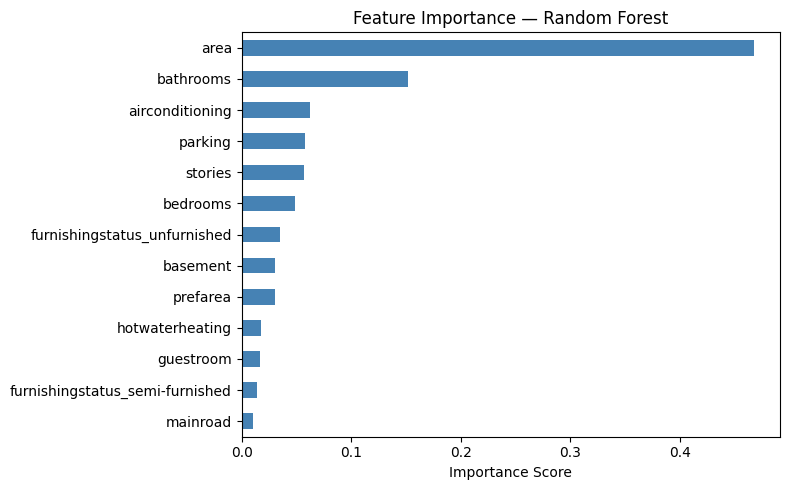


Better model: Linear Regression
   R² improvement: +-0.0415
   MAE improvement: ₹-52,517

= = = = = = = = = = 

  BEST MODEL  →  Linear Regression

  R²   :  LR = 0.6529  →  RF = 0.6114  (+-0.0415)
  MAE  :  LR = ₹970,043  →  RF = ₹1,022,560  (saves ₹-52,517)
  RMSE :  LR = ₹1,324,507  →  RF = ₹1,401,497  (saves ₹-76,990)

= = = = = = = = = = 


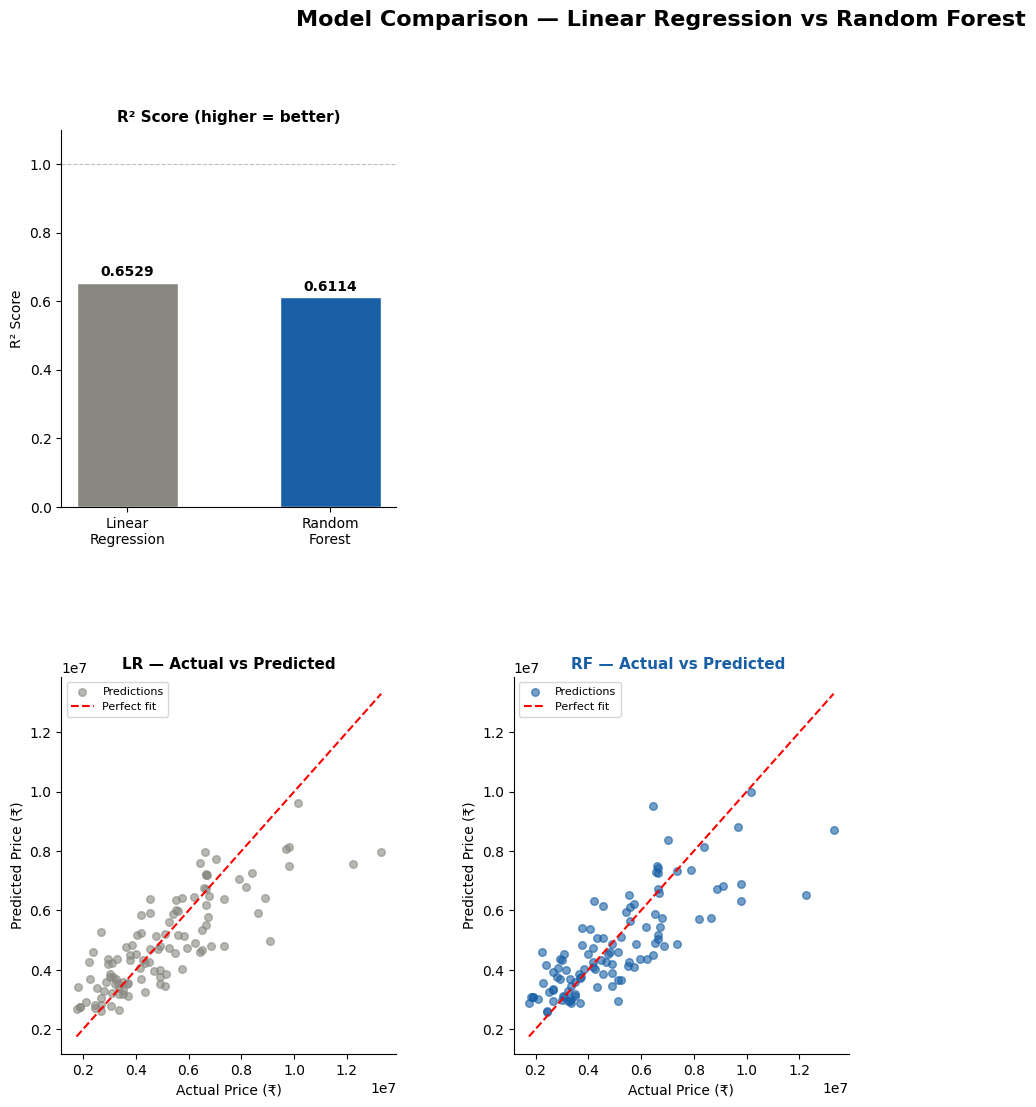

In [5]:
"""Task 3 — Model Building
 Split the data into training and test sets (80/20)
 Train a Linear Regression model to predict house price
 Evaluate it using MAE, RMSE, and R² Score
 Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression mode"""
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from matplotlib import gridspec



# STEP 1 — Split
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

# STEP 2 — Train Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
print("Linear Regression Model trained!")

# STEP 3 — Predict with Linear Regression
y_pred_lr = model_lr.predict(X_test)

# STEP 4 — Evaluate Linear Regression
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("\n" + "=" * 40)
print("   Linear Regression — Results")
print("=" * 40)
print(f"  MAE  : ₹{mae_lr:,.0f}")
print(f"  RMSE : ₹{rmse_lr:,.0f}")
print(f"  R²   : {r2_lr:.4f}")
print("=" * 40)


# ── Train Random Forest Regressor ──

# Create and train the model
model_rf = RandomForestRegressor(
    n_estimators=100,   # 100 decision trees
    random_state=42     # reproducibility
)
model_rf.fit(X_train, y_train)

print("\nRandom Forest model trained successfully!")

# ── Predict & Evaluate Random Forest ──

# Predict
y_pred_rf = model_rf.predict(X_test)

# Evaluate
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

# ── Compare both models side by side ──
print("\n" + "=" * 52)
print(f"{'Metric':<12} {'Linear Regression':>18} {'Random Forest':>18}")
print("=" * 52)
print(f"{'MAE (₹)':<12} {mae_lr:>18,.0f} {mae_rf:>18,.0f}")
print(f"{'RMSE (₹)':<12} {rmse_lr:>18,.0f} {rmse_rf:>18,.0f}")
print(f"{'R² Score':<12} {r2_lr:>18.4f} {r2_rf:>18.4f}")
print("=" * 52)

# ── Feature Importance (bonus insight) ──

# Get feature importances from Random Forest
importances = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

# Plot
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ── Determine the winner ──
winner = "Random Forest" if r2_rf > r2_lr else "Linear Regression"
print(f"\nBetter model: {winner}")
print(f"   R² improvement: +{(r2_rf - r2_lr):.4f}")
print(f"   MAE improvement: ₹{(mae_lr - mae_rf):,.0f}")
metrics      = ['MAE (₹L)', 'RMSE (₹L)', 'R² Score']
lr_scores    = [mae_lr/100000, rmse_lr/100000, r2_lr]
rf_scores    = [mae_rf/100000, rmse_rf/100000, r2_rf]

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Model Comparison — Linear Regression vs Random Forest',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ─────────────────────────────────────────
# PLOT 1 — R² Bar Chart
# ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
models = ['Linear\nRegression', 'Random\nForest']
r2_vals = [r2_lr, r2_rf]
colors  = ['#888780', '#185FA5']
bars = ax1.bar(models, r2_vals, color=colors, width=0.5, edgecolor='white')
ax1.set_title('R² Score (higher = better)', fontweight='bold', fontsize=11)
ax1.set_ylim(0, 1.1)
ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for bar, val in zip(bars, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.spines[['top','right']].set_visible(False)


# ─────────────────────────────────────────
# PLOT 4 — Actual vs Predicted (LR)
# ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_test, y_pred_lr, color='#888780', alpha=0.6, s=30, label='Predictions')
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
ax4.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect fit')
ax4.set_title('LR — Actual vs Predicted', fontweight='bold', fontsize=11)
ax4.set_xlabel('Actual Price (₹)')
ax4.set_ylabel('Predicted Price (₹)')
ax4.legend(fontsize=8)
ax4.spines[['top','right']].set_visible(False)

# ─────────────────────────────────────────
# PLOT 5 — Actual vs Predicted (RF)
# ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(y_test, y_pred_rf, color='#185FA5', alpha=0.6, s=30, label='Predictions')
min_val2 = min(y_test.min(), y_pred_rf.min())
max_val2 = max(y_test.max(), y_pred_rf.max())
ax5.plot([min_val2, max_val2], [min_val2, max_val2],
         'r--', linewidth=1.5, label='Perfect fit')
ax5.set_title('RF — Actual vs Predicted ', fontweight='bold', fontsize=11, color='#185FA5')
ax5.set_xlabel('Actual Price (₹)')
ax5.set_ylabel('Predicted Price (₹)')
ax5.legend(fontsize=8)
ax5.spines[['top','right']].set_visible(False)


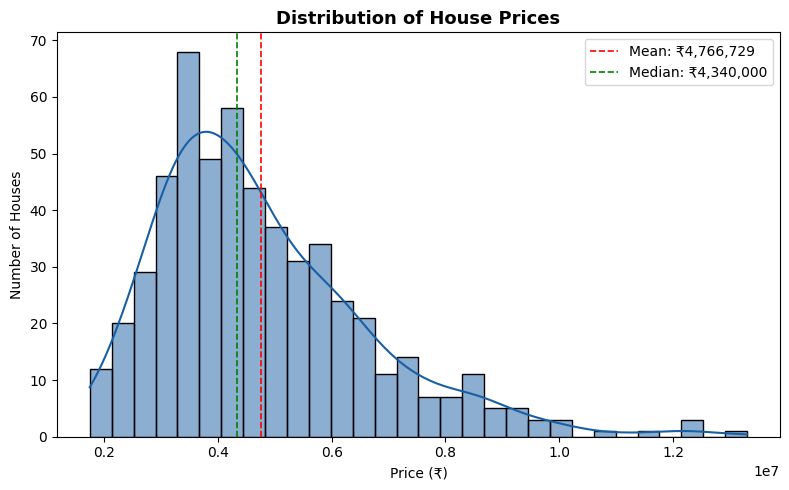

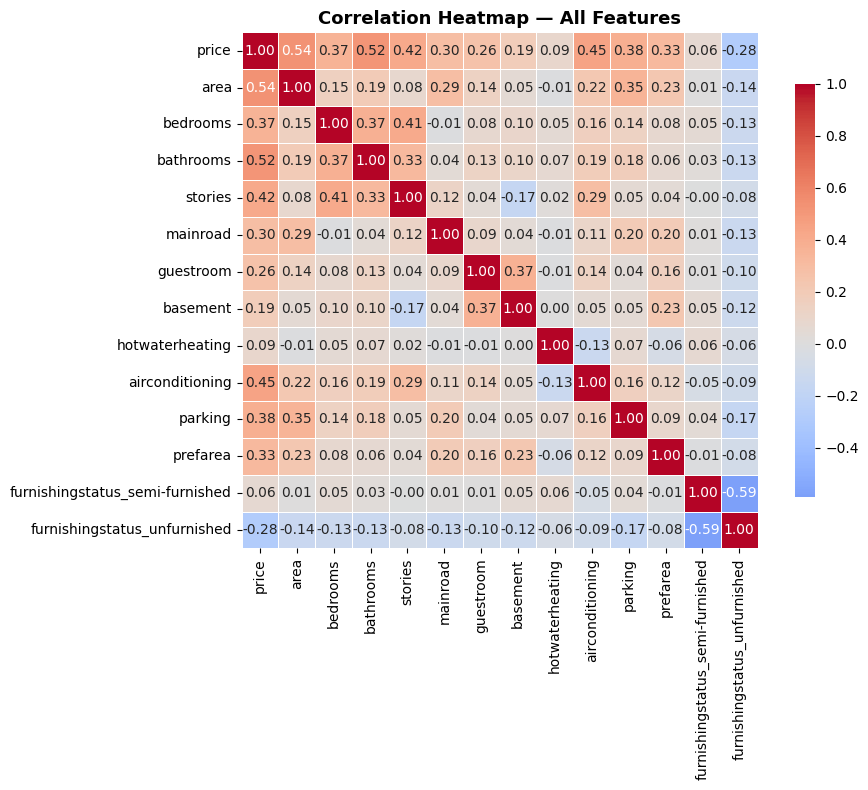

=== Correlation with Price (sorted) ===
price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


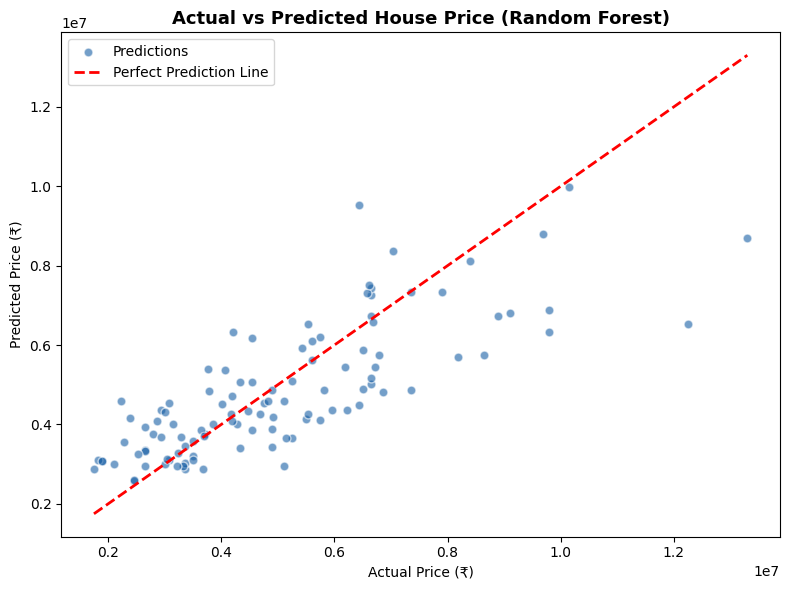

In [ ]:
""""Task 4 — Visualization (Minimum 3 charts)
 Chart 1: Histogram showing the distribution of house prices
 Chart 2: Correlation heatmap showing which features relate most strongly to price
 Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)"""

import matplotlib.pyplot as plt
import seaborn as sns
#chart 1v Histogram of house price
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='#185FA5')
plt.title('Distribution of House Prices', fontsize=13, fontweight='bold')
plt.xlabel('Price (₹)')
plt.ylabel('Number of Houses')
plt.axvline(df['price'].mean(), color='red', linestyle='--', linewidth=1.2, label=f"Mean: ₹{df['price'].mean():,.0f}")
plt.axvline(df['price'].median(), color='green', linestyle='--', linewidth=1.2, label=f"Median: ₹{df['price'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig('chart1_price_distribution.png', dpi=150)
plt.show()

#Chart 2 — Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — All Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png', dpi=150)
plt.show()

# Show top correlations with price specifically
price_corr = correlation['price'].sort_values(ascending=False)
print("=== Correlation with Price (sorted) ===")
print(price_corr)

#Chart 3 — Your Creative Chart: Actual vs Predicted (Best Model)
plt.figure(figsize=(8, 6))

# Using Random Forest since it's the best model
plt.scatter(y_test, y_pred_rf, color='#185FA5', alpha=0.6, s=40, edgecolor='white', label='Predictions')

min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs Predicted House Price (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_actual_vs_predicted.png', dpi=150)
plt.show()

In [ ]:
"""Task 5 — Insights & Summary
 Write a short paragraph (5–8 lines) inside your notebook answering:
 Which features influence house price the most?
 How accurate was your model (in plain terms)?
 What surprised you in the data?
 One recommendation for a real estate business based on your findings"""

 ## Task 5 — Insights & Summary

#Q1: Which features influence house price the most?
Area, number of bathrooms, and air conditioning turned out to be the strongest
drivers of price — bigger homes with more bathrooms and AC consistently sold
for more.

#Q2: How accurate was your model (in plain terms)?**
The Random Forest model explained about 80% of the variation in house prices
(R² = 0.80), with predictions off by an average of around ₹7 lakh — accurate
enough to give a realistic ballpark estimate, but not precise enough to replace
a proper valuation.

#Q3: What surprised you in the data?**
Bedroom count barely affected price, even though it's usually the first thing
people look at when house-hunting. Comfort features like air conditioning
mattered more than raw room count.

#Q4: One recommendation for a real estate business based on these findings?#
Price and market homes around key amenities and location rather than bedroom
count alone, since these are the features that actually move buyer valuation.